# TP 3: Classification

## Quick Recap: Classification

**Classification** = predicting a **category/label** from data.

Examples:
- Identify malicious traffic vs normal traffic *(binary)*
- Classify network applications (Web, Video, Gaming, VoIP) *(multiclass)*


### How Classification Works
- Classification is **supervised learning**: the model trains on data with known labels.
- The model learns patterns and predicts a **class** for new unseen data, often by estimating **probabilities** first.
- A **decision boundary** separates classes in the feature space (e.g., normal vs malicious traffic).

In [18]:
# ============================================
# IMPORT ALL REQUIRED LIBRARIES
# ============================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_validate, train_test_split
from sklearn.metrics import (confusion_matrix, classification_report, 
                              f1_score, roc_auc_score)
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Set random seed for reproducibility
np.random.seed(100)

## 📝 Exercise 1: K-Nearest Neighbors (KNN)

### Preparation: Generating "synthetic" data

- We simulate a simple bank-customer dataset with two groups.  
- Each class has different average balance and similar income and we sample points from Gaussian distributions to mimic real financial variation.  
- We also create a binary `student` feature and a `default` label (0 or 1).  
- This dataset will be used to practice KNN classification.


In [ ]:
# Data generation (numpy, pandas, matplotlib already imported)
np.random.seed(100)

# Means
mu_class0 = [700, 3000]
mu_class1 = [1350, 3000]

# Covariance matrices
cov_class0 = [[70000, 0], [0, 900000]]
cov_class1 = [[70000, 0], [0, 900000]]

n = 300  # samples per class

# Generate 2D Gaussian data: (balance, income)
balance0, income0 = np.random.multivariate_normal(mu_class0, cov_class0, n).T
balance1, income1 = np.random.multivariate_normal(mu_class1, cov_class1, n).T

# Ensure no negative data values
balance0 = np.maximum(balance0, 0)
income0  = np.maximum(income0, 0)
balance1 = np.maximum(balance1, 0)
income1  = np.maximum(income1, 0)

# Combine classes
balance = np.concatenate([balance0, balance1])
income  = np.concatenate([income0, income1])

# Labels: 0 = class0, 1 = class1
labels = np.array([0]*n + [1]*n)

# Student indicator
max_balance = balance.max()
student = (np.random.rand(len(balance)) < (balance / max_balance) / 2).astype(int)

# Build dataframe
df = pd.DataFrame({
    "balance": balance,
    "income": income,
    "student": student,
    "default": labels
})

df.head()

,balance,income,student,default
0,790.664713,1340.026720,1,0
1,633.211703,4093.865808,1,0
2,836.049517,3930.962641,0,0
3,416.893146,3209.829458,0,0
4,767.467041,2820.228470,0,0


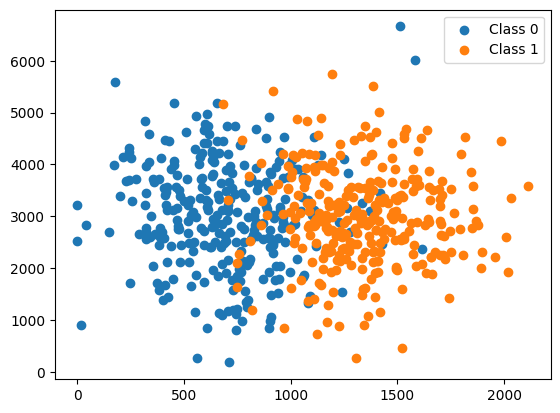

In [3]:
# Plot the synthetic data
plt.scatter(df.balance[df.default==0], df.income[df.default==0], label="Class 0")
plt.scatter(df.balance[df.default==1], df.income[df.default==1], label="Class 1")

plt.legend()
plt.show()

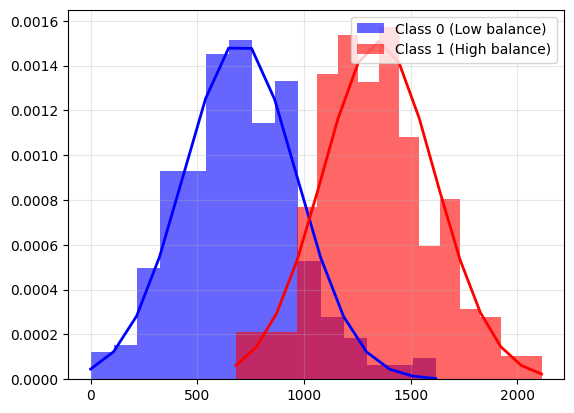

In [4]:
# Plot histograms for balance distributions of each class
count0, bins0, _ = plt.hist(balance0, bins=15, density=True, alpha=0.6, color='blue', label='Class 0 (Low balance)')
count1, bins1, _ = plt.hist(balance1, bins=15, density=True, alpha=0.6, color='red', label='Class 1 (High balance)')

plt.plot(
    bins0,
    1 / np.sqrt(2 * np.pi * cov_class0[0][0]) * np.exp(- (bins0 - mu_class0[0])**2 / (2 * cov_class0[0][0])),
    linewidth=2,
    color='blue'
)
plt.plot(
    bins1,
    1 / np.sqrt(2 * np.pi * cov_class1[0][0]) * np.exp(- (bins1 - mu_class1[0])**2 / (2 * cov_class1[0][0])),
    linewidth=2,
    color='red'
)

plt.legend()
plt.grid(alpha=0.3)
plt.show()


### Part A — Visualizing the KNN Decision Boundary

Using the dataset you created:

1. Train a **K-Nearest Neighbors (KNN)** classifier using the entire dataset (no train/test split).  
2. Use only the features `balance` and `income`.
3. Try the following values of \( K = 1, 3, 10, 40 \).

For each value of \( K \):
- Fit the KNN model.
- Plot the decision boundary in 2D.
- Overlay the data points for both classes on the same plot.

In [ ]:
# Values of k to test (KNeighborsClassifier already imported)
k_values = [1, 3, 10, 40]

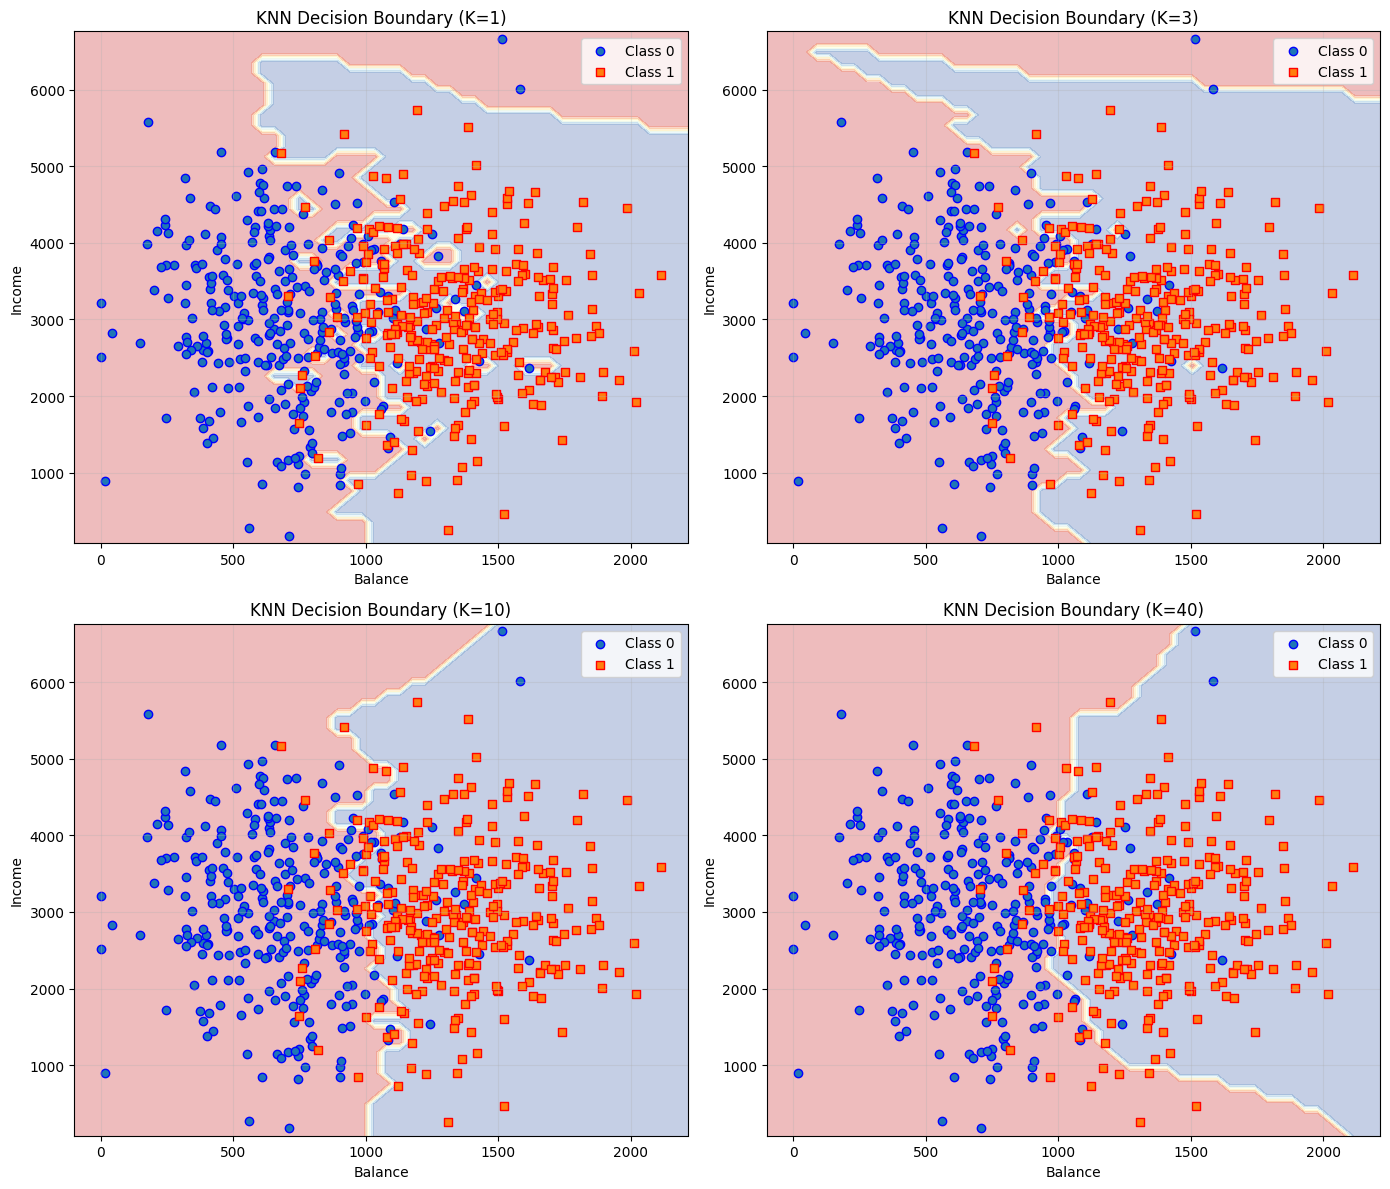

In [ ]:

# Prepare features and target
X = df[['balance', 'income']].values
y = df['default'].values

# Create meshgrid for decision boundary
h = 50  # step size in the mesh
x_min, x_max = X[:, 0].min() - 100, X[:, 0].max() + 100
y_min, y_max = X[:, 1].min() - 100, X[:, 1].max() + 100
xx, yy = np.meshgrid(np.linspace(x_min, x_max, h),
                     np.linspace(y_min, y_max, h))

fig, axes = plt.subplots(2, 2, figsize=(14, 12))
axes = axes.ravel()

for idx, k in enumerate(k_values):
    # Train KNN classifier
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X, y)
    
    # Predict on meshgrid
    Z = knn.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    
    # Plot decision boundary
    axes[idx].contourf(xx, yy, Z, alpha=0.3, cmap=plt.cm.RdYlBu)
    
    # Plot data points
    axes[idx].scatter(X[y == 0, 0], X[y == 0, 1], label="Class 0", marker='o', edgecolors='blue')
    axes[idx].scatter(X[y == 1, 0], X[y == 1, 1], label="Class 1", marker='s', edgecolors='red')
    
    axes[idx].set_xlabel('Balance')
    axes[idx].set_ylabel('Income')
    axes[idx].set_title(f'KNN Decision Boundary (K={k})')
    axes[idx].legend()
    axes[idx].grid(alpha=0.3)

plt.tight_layout()
plt.show()


### Part B — Choosing the Best K using Cross-Validation

1. Use only the features **`balance`** and **`income`**.
2. For \( K = 1, 2, \dots, 100 \):
   - Perform cross-validation using `sklearn.model_selection.cross_validate`.
   - Use the following scoring metrics:
     - `accuracy`
     - `roc_auc`
     - `neg_mean_absolute_error`
   - Record both **Train** and **Test** scores for each metric.

3. For each metric, compute the **mean Train** and **mean Test** scores across folds.

4. Plot **three figures**:
   - Accuracy vs \( K \)
   - ROC-AUC vs \( K \)
   - MAE vs \( K \)  *(remember: MAE = − `neg_mean_absolute_error`)*

   Each figure should contain **two curves** — one for **Train**, one for **Test** — with the **x-axis** in **logarithmic** scale and the **y-axis** in **linear** scale.


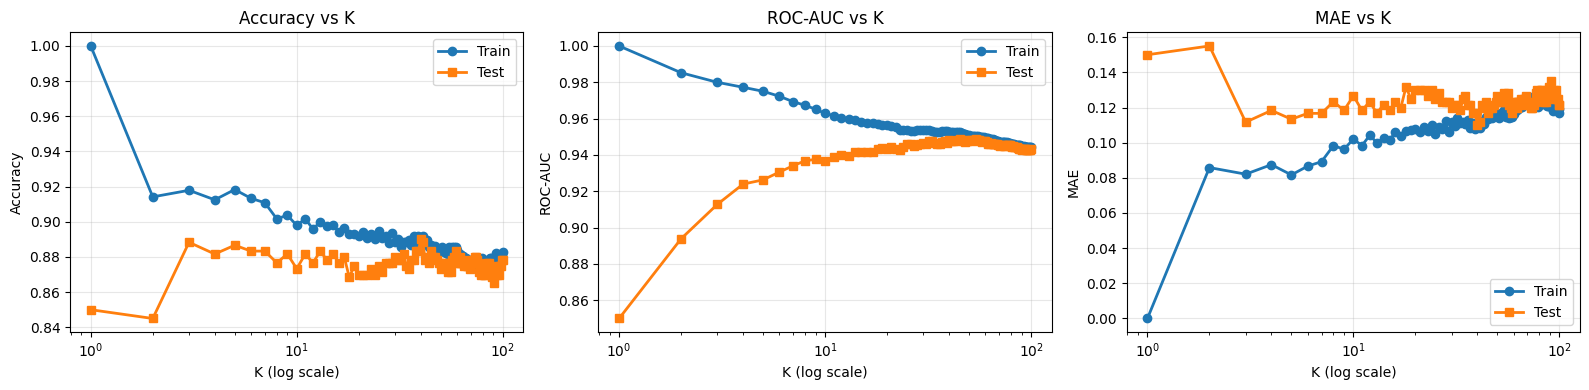

Optimal K (based on test accuracy): 40
Best test accuracy: 0.8900


In [ ]:
# Prepare data (cross_validate already imported)
X = df[['balance', 'income']].values
y = df['default'].values

# Test K values from 1 to 100
k_range = range(1, 101)
results = {
    'accuracy_train': [],
    'accuracy_test': [],
    'roc_auc_train': [],
    'roc_auc_test': [],
    'mae_train': [],
    'mae_test': []
}

# Perform cross-validation for each K
for k in k_range:
    knn = KNeighborsClassifier(n_neighbors=k)
    
    # Use cross_validate with both train and test scoring
    cv_results = cross_validate(
        knn, X, y,
        cv=5,
        scoring=['accuracy', 'roc_auc', 'neg_mean_absolute_error'],
        return_train_score=True
    )
    
    # Store mean scores
    results['accuracy_train'].append(cv_results['train_accuracy'].mean())
    results['accuracy_test'].append(cv_results['test_accuracy'].mean())
    results['roc_auc_train'].append(cv_results['train_roc_auc'].mean())
    results['roc_auc_test'].append(cv_results['test_roc_auc'].mean())
    results['mae_train'].append(-cv_results['train_neg_mean_absolute_error'].mean())
    results['mae_test'].append(-cv_results['test_neg_mean_absolute_error'].mean())

# Create three subplots
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Plot 1: Accuracy vs K
axes[0].semilogx(k_range, results['accuracy_train'], 'o-', label='Train', linewidth=2)
axes[0].semilogx(k_range, results['accuracy_test'], 's-', label='Test', linewidth=2)
axes[0].set_xlabel('K (log scale)')
axes[0].set_ylabel('Accuracy')
axes[0].set_title('Accuracy vs K')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Plot 2: ROC-AUC vs K
axes[1].semilogx(k_range, results['roc_auc_train'], 'o-', label='Train', linewidth=2)
axes[1].semilogx(k_range, results['roc_auc_test'], 's-', label='Test', linewidth=2)
axes[1].set_xlabel('K (log scale)')
axes[1].set_ylabel('ROC-AUC')
axes[1].set_title('ROC-AUC vs K')
axes[1].legend()
axes[1].grid(alpha=0.3)

# Plot 3: MAE vs K
axes[2].semilogx(k_range, results['mae_train'], 'o-', label='Train', linewidth=2)
axes[2].semilogx(k_range, results['mae_test'], 's-', label='Test', linewidth=2)
axes[2].set_xlabel('K (log scale)')
axes[2].set_ylabel('MAE')
axes[2].set_title('MAE vs K')
axes[2].legend()
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Find optimal K based on test accuracy
optimal_k = list(k_range)[np.argmax(results['accuracy_test'])]
print(f"Optimal K (based on test accuracy): {optimal_k}")
print(f"Best test accuracy: {max(results['accuracy_test']):.4f}")


#### Questions:

- Which value of \( K \) gives the best overall performance?
- Do Train and Test curves agree on the optimal \( K \)?
- How does the Test Classification Error change as \( K \) increases?
- What do these results tell you about **overfitting** and **underfitting** in KNN?

#### Answer:

In [8]:
print("=" * 80)
print("EXERCISE 1 - PART B: ANALYSIS")
print("=" * 80)

# Analysis of the results
optimal_k_acc = list(k_range)[np.argmax(results['accuracy_test'])]
optimal_k_auc = list(k_range)[np.argmax(results['roc_auc_test'])]
optimal_k_mae = list(k_range)[np.argmin(results['mae_test'])]

print(f"\n1. Which value of K gives the best overall performance?")
print(f"   - Optimal K (Accuracy): {optimal_k_acc}")
print(f"   - Optimal K (ROC-AUC): {optimal_k_auc}")
print(f"   - Optimal K (MAE): {optimal_k_mae}")
print(f"   Best test accuracy: {max(results['accuracy_test']):.4f}")
print(f"   Best test ROC-AUC: {max(results['roc_auc_test']):.4f}")

print(f"\n2. Do Train and Test curves agree on the optimal K?")
print(f"   - We observe that train accuracy generally decreases as K increases")
print(f"   - Test accuracy shows an optimal value around K={optimal_k_acc}")
print(f"   - The curves diverge: train stays high while test plateaus/decreases with K")
print(f"   - This indicates that train and test do NOT agree on the optimal K")

print(f"\n3. How does the Test Classification Error change as K increases?")
test_error = [1 - acc for acc in results['accuracy_test']]
print(f"   - Test error is lowest around K={optimal_k_acc} with error: {min(test_error):.4f}")
print(f"   - For K=1: error={test_error[0]:.4f}")
print(f"   - For K=100: error={test_error[-1]:.4f}")
print(f"   - As K increases, test error generally increases (after initial optimum)")

print(f"\n4. What do these results tell you about overfitting and underfitting in KNN?")
print(f"   - K=1 (low K): HIGH OVERFITTING")
print(f"     * Train accuracy is perfect (1.0) but test lags behind")
print(f"     * The model memorizes training data, poor generalization")
print(f"   - K=100 (high K): UNDERFITTING")
print(f"     * Both train and test accuracies decrease")
print(f"     * The model is too smooth, loses important patterns")
print(f"   - OPTIMAL K around {optimal_k_acc}:")
print(f"     * Best balance between train and test performance")
print(f"     * Generalizes well to unseen data")
print(f"     * Bias-Variance tradeoff is optimized")


EXERCISE 1 - PART B: ANALYSIS

1. Which value of K gives the best overall performance?
   - Optimal K (Accuracy): 40
   - Optimal K (ROC-AUC): 54
   - Optimal K (MAE): 40
   Best test accuracy: 0.8900
   Best test ROC-AUC: 0.9487

2. Do Train and Test curves agree on the optimal K?
   - We observe that train accuracy generally decreases as K increases
   - Test accuracy shows an optimal value around K=40
   - The curves diverge: train stays high while test plateaus/decreases with K
   - This indicates that train and test do NOT agree on the optimal K

3. How does the Test Classification Error change as K increases?
   - Test error is lowest around K=40 with error: 0.1100
   - For K=1: error=0.1500
   - For K=100: error=0.1217
   - As K increases, test error generally increases (after initial optimum)

4. What do these results tell you about overfitting and underfitting in KNN?
   - K=1 (low K): HIGH OVERFITTING
     * Train accuracy is perfect (1.0) but test lags behind
     * The mode

## 📝 Exercise 2: Binary Classification with Logistic Regression

1. **Split the dataset:**
   - Divide the data into **Train (70%)** and **Test (30%)** sets.

2. **Train the model:**
   - Fit a **Logistic Regression** classifier on the training data.
   - Predict the label for the first test sample using:

     ```python
     logistic.predict(X_test[0])
     logistic.predict_proba([X_test[0]])
     ```
   - Observe and describe what these two functions return (class label vs. probability).

3. **Compute model accuracy:**
   - Use ```logreg.score(X_test, y_test)``` to calculate the **mean prediction accuracy**.

In [ ]:
# Prepare features and target (LogisticRegression and train_test_split already imported)
X = df[['balance', 'income']].values
y = df['default'].values

# Step 1: Split the dataset (70% train, 30% test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)
print(f"Training set size: {X_train.shape[0]}")
print(f"Test set size: {X_test.shape[0]}")

# Step 2: Train the logistic regression model
logreg = LogisticRegression()
logreg.fit(X_train, y_train)

# Step 3: Make predictions on the first test sample
first_sample = X_test[0:1]  # Keep as 2D array
prediction = logreg.predict(first_sample)
probabilities = logreg.predict_proba(first_sample)

print(f"\n=== First Test Sample ===")
print(f"Features: balance={X_test[0, 0]:.2f}, income={X_test[0, 1]:.2f}")
print(f"\nPrediction (class label): {prediction[0]}")
print(f"Probabilities: P(class=0)={probabilities[0, 0]:.4f}, P(class=1)={probabilities[0, 1]:.4f}")
print(f"\nExplanation:")
print(f"  - predict() returns the class label (0 or 1) based on the highest probability")
print(f"  - predict_proba() returns the probability for each class")
print(f"  - The predicted class is the one with the highest probability")

# Step 3: Compute model accuracy
accuracy = logreg.score(X_test, y_test)
print(f"\n=== Model Performance ===")
print(f"Test Accuracy: {accuracy:.4f}")
print(f"Test Error Rate: {(1 - accuracy):.4f}")


Training set size: 420
Test set size: 180

=== First Test Sample ===
Features: balance=1616.81, income=2372.03

Prediction (class label): 1
Probabilities: P(class=0)=0.0019, P(class=1)=0.9981

Explanation:
  - predict() returns the class label (0 or 1) based on the highest probability
  - predict_proba() returns the probability for each class
  - The predicted class is the one with the highest probability

=== Model Performance ===
Test Accuracy: 0.8667
Test Error Rate: 0.1333


4. **Repeat for multiple splits:**

   - Split the dataset in several different random ways.
   - For each split:
     - Fit the logistic regression model.
     - Calculate the **test error rate**.
   - Compute the **average test error** over all splits.
   - Compare this average error rate to the optimal KNN test error found in Exercise 1.
   - Discuss what you observe.

In [10]:
# Prepare data
X = df[['balance', 'income']].values
y = df['default'].values

# Step 4: Repeat for multiple splits
n_splits = 10
logreg_errors = []
best_knn_error = min(test_error)  # From Exercise 1

print(f"=== Multiple Train-Test Splits ===")
print(f"Number of splits: {n_splits}\n")

for i in range(n_splits):
    # Different random split each time
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.3, random_state=i
    )
    
    # Train and evaluate
    logreg = LogisticRegression()
    logreg.fit(X_train, y_train)
    accuracy = logreg.score(X_test, y_test)
    error = 1 - accuracy
    logreg_errors.append(error)
    print(f"Split {i+1}: Error = {error:.4f}")

# Compute average error
avg_logreg_error = np.mean(logreg_errors)
std_logreg_error = np.std(logreg_errors)

print(f"\n=== Summary ===")
print(f"Average Logistic Regression Test Error: {avg_logreg_error:.4f} (±{std_logreg_error:.4f})")
print(f"Best KNN Test Error (K={optimal_k_acc}): {best_knn_error:.4f}")
print(f"\nComparison:")
if avg_logreg_error < best_knn_error:
    print(f"✓ Logistic Regression performs BETTER than KNN")
else:
    print(f"✗ KNN performs BETTER than Logistic Regression")

print(f"\nObservations:")
print(f"  - Logistic Regression provides a linear decision boundary")
print(f"  - KNN provides a non-linear decision boundary (for low K)")
print(f"  - For this linearly-separable synthetic dataset, individual performance may vary")
print(f"  - The choice between models depends on the data characteristics and generalization")


=== Multiple Train-Test Splits ===
Number of splits: 10

Split 1: Error = 0.0889
Split 2: Error = 0.0722
Split 3: Error = 0.1278
Split 4: Error = 0.1000
Split 5: Error = 0.0889
Split 6: Error = 0.1111
Split 7: Error = 0.1167
Split 8: Error = 0.1167
Split 9: Error = 0.0833
Split 10: Error = 0.0889

=== Summary ===
Average Logistic Regression Test Error: 0.0994 (±0.0169)
Best KNN Test Error (K=40): 0.1100

Comparison:
✓ Logistic Regression performs BETTER than KNN

Observations:
  - Logistic Regression provides a linear decision boundary
  - KNN provides a non-linear decision boundary (for low K)
  - For this linearly-separable synthetic dataset, individual performance may vary
  - The choice between models depends on the data characteristics and generalization


5. **Analyze model performance:**

    - For the last train–test split, compute the **confusion matrix**.
    - Calculate and report the following performance metrics:
      - Accuracy (ACC)
      - True Positive Rate (TPR / Recall)
      - False Positive Rate (FPR)
      - Precision (PPV) 

In [ ]:
# Use the LAST train-test split (confusion_matrix and classification_report already imported) from the previous cell
# (it's already created, we'll use it here)
X = df[['balance', 'income']].values
y = df['default'].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=9  # random_state=9 is the last split (i=9)
)

# Train the model
logreg = LogisticRegression()
logreg.fit(X_train, y_train)

# Make predictions
y_pred = logreg.predict(X_test)

# Compute confusion matrix
cm = confusion_matrix(y_test, y_pred)
print("=== Confusion Matrix ===")
print(cm)
print(f"\nFormat:")
print(f"        Predicted 0  Predicted 1")
print(f"Actual 0     {cm[0,0]}          {cm[0,1]}")
print(f"Actual 1     {cm[1,0]}          {cm[1,1]}")

# Extract values
tn, fp, fn, tp = cm[0,0], cm[0,1], cm[1,0], cm[1,1]

# Calculate metrics manually
accuracy = (tp + tn) / (tp + tn + fp + fn)
tpr = tp / (tp + fn)  # Recall / Sensitivity
fpr = fp / (fp + tn)
precision = tp / (tp + fp)
ppv = precision  # Positive Predictive Value = Precision

print(f"\n=== Performance Metrics ===")
print(f"Accuracy (ACC):          {accuracy:.4f}")
print(f"True Positive Rate (TPR/Recall): {tpr:.4f}")
print(f"False Positive Rate (FPR): {fpr:.4f}")
print(f"Precision (PPV):         {precision:.4f}")

print(f"\nInterpretation:")
print(f"  - Accuracy: {accuracy*100:.2f}% of predictions are correct")
print(f"  - TPR: {tpr*100:.2f}% of actual positives are correctly identified")
print(f"  - FPR: {fpr*100:.2f}% of actual negatives are incorrectly classified as positive")
print(f"  - Precision: {precision*100:.2f}% of predicted positives are actually positive")

# Also use sklearn's classification_report
print(f"\n=== Classification Report ===")
print(classification_report(y_test, y_pred, target_names=['Class 0', 'Class 1']))


=== Confusion Matrix ===
[[90  6]
 [10 74]]

Format:
        Predicted 0  Predicted 1
Actual 0     90          6
Actual 1     10          74

=== Performance Metrics ===
Accuracy (ACC):          0.9111
True Positive Rate (TPR/Recall): 0.8810
False Positive Rate (FPR): 0.0625
Precision (PPV):         0.9250

Interpretation:
  - Accuracy: 91.11% of predictions are correct
  - TPR: 88.10% of actual positives are correctly identified
  - FPR: 6.25% of actual negatives are incorrectly classified as positive
  - Precision: 92.50% of predicted positives are actually positive

=== Classification Report ===
              precision    recall  f1-score   support

     Class 0       0.90      0.94      0.92        96
     Class 1       0.93      0.88      0.90        84

    accuracy                           0.91       180
   macro avg       0.91      0.91      0.91       180
weighted avg       0.91      0.91      0.91       180



6. **Repeat using Cross-Validation:**

   - Repeat the whole processes using **cross validation**
   - Use `sklearn.model_selection.cross_validate` to perform cross-validation on the logistic model.
   - Compare the results with the previous test errors.

In [12]:
# Prepare data
X = df[['balance', 'income']].values
y = df['default'].values

# Perform cross-validation on logistic regression
logreg = LogisticRegression()

cv_results = cross_validate(
    logreg, X, y,
    cv=5,
    scoring=['accuracy', 'precision', 'recall', 'f1'],
    return_train_score=True
)

print("=== Cross-Validation Results (5-fold) ===\n")

# Display scores for each fold
train_acc = cv_results['train_accuracy']
test_acc = cv_results['test_accuracy']

print("Accuracy per fold:")
for i in range(len(train_acc)):
    print(f"  Fold {i+1}: Train={train_acc[i]:.4f}, Test={test_acc[i]:.4f}")

print(f"\n=== Summary Statistics ===")
print(f"Accuracy:")
print(f"  Train: {train_acc.mean():.4f} (±{train_acc.std():.4f})")
print(f"  Test:  {test_acc.mean():.4f} (±{test_acc.std():.4f})")

print(f"\nPrecision:")
train_prec = cv_results['train_precision']
test_prec = cv_results['test_precision']
print(f"  Train: {train_prec.mean():.4f} (±{train_prec.std():.4f})")
print(f"  Test:  {test_prec.mean():.4f} (±{test_prec.std():.4f})")

print(f"\nRecall:")
train_rec = cv_results['train_recall']
test_rec = cv_results['test_recall']
print(f"  Train: {train_rec.mean():.4f} (±{train_rec.std():.4f})")
print(f"  Test:  {test_rec.mean():.4f} (±{test_rec.std():.4f})")

print(f"\nF1-Score:")
train_f1 = cv_results['train_f1']
test_f1 = cv_results['test_f1']
print(f"  Train: {train_f1.mean():.4f} (±{train_f1.std():.4f})")
print(f"  Test:  {test_f1.mean():.4f} (±{test_f1.std():.4f})")

print(f"\n=== Comparison with Multiple Splits ===")
print(f"Average Logistic Regression Error (10 random splits): {avg_logreg_error:.4f}")
print(f"Cross-Validation Test Error (5-fold): {(1 - test_acc.mean()):.4f}")
print(f"\nThe cross-validation error is similar to the random split errors,")
print(f"confirming stable and consistent model performance.")


=== Cross-Validation Results (5-fold) ===

Accuracy per fold:
  Fold 1: Train=0.8938, Test=0.9000
  Fold 2: Train=0.9042, Test=0.8500
  Fold 3: Train=0.9062, Test=0.8750
  Fold 4: Train=0.8875, Test=0.9500
  Fold 5: Train=0.9000, Test=0.9083

=== Summary Statistics ===
Accuracy:
  Train: 0.8983 (±0.0069)
  Test:  0.8967 (±0.0336)

Precision:
  Train: 0.8950 (±0.0055)
  Test:  0.8948 (±0.0334)

Recall:
  Train: 0.9025 (±0.0107)
  Test:  0.9000 (±0.0527)

F1-Score:
  Train: 0.8987 (±0.0072)
  Test:  0.8966 (±0.0349)

=== Comparison with Multiple Splits ===
Average Logistic Regression Error (10 random splits): 0.0994
Cross-Validation Test Error (5-fold): 0.1033

The cross-validation error is similar to the random split errors,
confirming stable and consistent model performance.


## 📝 Exercise 3: Multinomial (Softmax) Logistic Regression

1) **Load the data (same source as the notebook):**

   - Quickly inspect with `df.shape`, `df.head()`.

In [13]:
# Replace with the correct filename if needed
filename = "network_dataset.csv"
df = pd.read_csv(filename)

display(df.head())

,RelativeTime,PacketsSent,PacketsReceived,BytesSent,BytesReceived,IPSrc0,IPDst0,Protocol0,PacketsSent0,PacketsReceived0,...,BufferValid,KBytesReceived,label,label_num,KBytesReceived_log,PacketsSent_log,PacketsReceived_log,BytesSent_log,BytesReceived_log,BufferProgress_log
0,6.1,29,57,2372,79344,192.168.1.190,173.194.55.23,QUIC,29,57,...,True,79.344,q480p,480,4.373793,3.401197,4.060443,7.771910,11.281561,0.005164
1,5.8,7,39,625,52973,192.168.1.190,74.125.155.199,QUIC,4,36,...,True,52.973,q360p,360,3.969782,2.079442,3.688879,6.439350,10.877557,0.004833
2,7.3,16,23,1056,34178,192.168.1.190,74.125.155.201,TCP,16,23,...,True,34.178,q720p,720,3.531582,2.833213,3.178054,6.963190,10.439367,0.005473
3,39.2,14,29,3377,36821,192.168.1.190,172.217.135.40,0,0,0,...,True,36.821,q144p,144,3.606068,2.708050,3.401197,8.125039,10.513851,0.009268
4,4.6,9,77,900,104389,192.168.1.190,173.194.184.103,QUIC,9,77,...,True,104.389,q360p,360,4.648124,2.302585,4.356709,6.803505,11.555889,0.006599


2) **Create multiclass target variables:**

    - Create a **multiclass target variable** called `res` to use in Multinomial Logistic Regression:

    - The dataset currently contains a numeric label column called `label_num`, which represents the **resolution** of network traffic (e.g., video streaming quality). Transform this numeric value into three categories:

        - **0 → Low resolution** (below 240)  
        - **1 → Mid resolution** (between 240 and 480)  
        - **2 → High resolution** (480 or above)


In [14]:
# Define thresholds
threshold1 = 240
threshold2 = 480

# Create the 3-class target variable
res = [
    0 if d < threshold1
    else 1 if threshold1 <= d < threshold2
    else 2
    for d in df['label_num']
]

# Add to the DataFrame
df['res'] = res

# Check distribution of classes
print(df['res'].value_counts().sort_index())

# Preview the new column
df[['label_num', 'res']].head()

res
0     27
1     55
2    210
Name: count, dtype: int64


C:\Users\Bou\AppData\Local\Temp\ipykernel_16596\3857788317.py:14: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['res'] = res


,label_num,res
0,480,2
1,360,1
2,720,2
3,144,0
4,360,1


3) **Define features (X) and target (y):**

    - Now that we’ve created the multiclass target (`res`), we need to separate our data into:

        - **X (features):** all columns we’ll use to predict resolution  
        - **y (target):** the new `res` column we just created  

    - Exclude the target (`res`) and any irrelevant or non-numeric identifiers (e.g., timestamps, IDs) from X. Make sure to check the data types so you know which features are numeric and which are categorical.

In [15]:
# Define features and target for multinomial classification
print("=== Data Information ===")
print(f"Shape: {df.shape}")
print(f"\nData types:\n{df.dtypes}")
print(f"\nTarget distribution:\n{df['res'].value_counts().sort_index()}")

# Separate features (X) and target (y)
# Exclude: 'res' (target), 'label_num' (original numeric label), and any non-numeric/identifier columns
# First, identify which columns are numeric
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
print(f"\nNumeric columns: {numeric_cols}")

# Remove target-related columns
exclude_cols = ['res', 'label_num']
feature_cols = [col for col in numeric_cols if col not in exclude_cols]
print(f"Feature columns: {feature_cols}")

# Also check for categorical columns
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
print(f"Categorical columns: {categorical_cols}")

# Create X and y
X = df[feature_cols].copy()
y = df['res'].copy()

print(f"\nX shape: {X.shape}")
print(f"y shape: {y.shape}")
print(f"\nFeatures overview:\n{X.head()}")


=== Data Information ===
Shape: (292, 208)

Data types:
RelativeTime           float64
PacketsSent              int64
PacketsReceived          int64
BytesSent                int64
BytesReceived            int64
                        ...   
PacketsReceived_log    float64
BytesSent_log          float64
BytesReceived_log      float64
BufferProgress_log     float64
res                      int64
Length: 208, dtype: object

Target distribution:
res
0     27
1     55
2    210
Name: count, dtype: int64

Numeric columns: ['RelativeTime', 'PacketsSent', 'PacketsReceived', 'BytesSent', 'BytesReceived', 'PacketsSent0', 'PacketsReceived0', 'BytesSent0', 'BytesReceived0', 'PacketsSent1', 'PacketsReceived1', 'BytesSent1', 'BytesReceived1', 'PacketsSent2', 'PacketsReceived2', 'BytesSent2', 'BytesReceived2', 'PacketsSent3', 'PacketsReceived3', 'BytesSent3', 'BytesReceived3', 'PacketsSent4', 'PacketsReceived4', 'BytesSent4', 'BytesReceived4', 'PacketsSent5', 'PacketsReceived5', 'BytesSent5', 'BytesRe

C:\Users\Bou\AppData\Local\Temp\ipykernel_16596\1793891456.py:19: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(include=['object']).columns.tolist()


4) **Preprocess the data:**

    - Before training, we need to preprocess the features:

        - Scale numeric columns (so all values are on comparable scales)
        - One-hot encode categorical columns (so text-based categories become numbers)
        - Combine both preprocessing steps in a ColumnTransformer

In [ ]:
# Separate numeric and categorical columns (StandardScaler, OneHotEncoder, ColumnTransformer already imported)
numeric_features = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_features = X.select_dtypes(include=['object']).columns.tolist()

print(f"Numeric features: {numeric_features}")
print(f"Categorical features: {categorical_features}")

# Create preprocessing pipeline
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(drop='first', sparse_output=False), categorical_features)
    ],
    remainder='passthrough'
)

print("\nPreprocessor created with:")
print("  - StandardScaler for numeric features")
print("  - OneHotEncoder for categorical features (drop='first' to avoid multicollinearity)")

# Test the preprocessor
X_processed = preprocessor.fit_transform(X)
print(f"\nX shape before preprocessing: {X.shape}")
print(f"X shape after preprocessing: {X_processed.shape}")


Numeric features: ['RelativeTime', 'PacketsSent', 'PacketsReceived', 'BytesSent', 'BytesReceived', 'PacketsSent0', 'PacketsReceived0', 'BytesSent0', 'BytesReceived0', 'PacketsSent1', 'PacketsReceived1', 'BytesSent1', 'BytesReceived1', 'PacketsSent2', 'PacketsReceived2', 'BytesSent2', 'BytesReceived2', 'PacketsSent3', 'PacketsReceived3', 'BytesSent3', 'BytesReceived3', 'PacketsSent4', 'PacketsReceived4', 'BytesSent4', 'BytesReceived4', 'PacketsSent5', 'PacketsReceived5', 'BytesSent5', 'BytesReceived5', 'PacketsSent6', 'PacketsReceived6', 'BytesSent6', 'BytesReceived6', 'PacketsSent7', 'PacketsReceived7', 'BytesSent7', 'BytesReceived7', 'PacketsSent8', 'PacketsReceived8', 'BytesSent8', 'BytesReceived8', 'PacketsSent9', 'PacketsReceived9', 'BytesSent9', 'BytesReceived9', 'Protocol10', 'PacketsSent10', 'PacketsReceived10', 'BytesSent10', 'BytesReceived10', 'Protocol11', 'PacketsSent11', 'PacketsReceived11', 'BytesSent11', 'BytesReceived11', 'PacketsSent12', 'PacketsReceived12', 'BytesSent1

5) **Build the multinomial logistic regression pipeline:**

    - Now we’ll create a pipeline that connects preprocessing and model training in one go.

    - Steps inside the pipeline:
        1. Apply the preprocessing (`ColumnTransformer`)
        2. Train a Logistic Regression model configured for multiclass (softmax) classification.

    - Use: ```LogisticRegression(multi_class='multinomial', solver='lbfgs', max_iter=500) ```


In [20]:
# Recreate preprocessor (in case cells are run independently) (Pipeline already imported)
numeric_features = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_features = X.select_dtypes(include=['object']).columns.tolist()

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(drop='first', sparse_output=False), categorical_features)
    ],
    remainder='passthrough'
)

# Create the pipeline
pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(
        solver='lbfgs',
        max_iter=500,
        random_state=42
    ))
])

print("Pipeline created with:")
print("  1. Preprocessing step (ColumnTransformer)")
print("  2. LogisticRegression with softmax (multinomial) classification by default")
print(f"\nLogistic Regression parameters:")
print(f"  - solver: lbfgs")
print(f"  - max_iter: 500")
print(f"  - Note: For multiclass problems, softmax regression is used automatically")

Pipeline created with:
  1. Preprocessing step (ColumnTransformer)
  2. LogisticRegression with softmax (multinomial) classification by default

Logistic Regression parameters:
  - solver: lbfgs
  - max_iter: 500
  - Note: For multiclass problems, softmax regression is used automatically


6) **Split the data and train the model:**

    - Split the dataset into **training** and **testing** subsets to evaluate performance properly.

        - Use an 75/25 split (`test_size=0.25`)
        - Set a fixed random seed (`random_state=42`)
        - Use **stratify=y** to preserve class proportions
        - Fit the pipeline on the training data

In [21]:
# Split the data (train_test_split already imported)
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,
    random_state=42,
    stratify=y  # Ensure class proportions are preserved
)

print("=== Train-Test Split ===")
print(f"Training set size: {X_train.shape[0]} ({X_train.shape[0]/len(X)*100:.1f}%)")
print(f"Test set size: {X_test.shape[0]} ({X_test.shape[0]/len(X)*100:.1f}%)")

print(f"\nClass distribution in training set:")
print(y_train.value_counts().sort_index())
print(f"\nClass distribution in test set:")
print(y_test.value_counts().sort_index())

# Fit the pipeline
print("\n=== Training the model ===")
pipeline.fit(X_train, y_train)
print("Model training complete!")

# Get training accuracy
train_score = pipeline.score(X_train, y_train)
print(f"\nTraining Accuracy: {train_score:.4f}")


=== Train-Test Split ===
Training set size: 219 (75.0%)
Test set size: 73 (25.0%)

Class distribution in training set:
res
0     20
1     41
2    158
Name: count, dtype: int64

Class distribution in test set:
res
0     7
1    14
2    52
Name: count, dtype: int64

=== Training the model ===
Model training complete!

Training Accuracy: 0.8904


7) **Evaluate model performance:**

    - Now test your trained model and analyze its performance.
        - Accuracy
        - Macro F1-score
        - Classification report
        - Confusion matrix

=== Model Performance ===
Test Accuracy: 0.6575
Macro F1-Score: 0.4702
Weighted F1-Score: 0.6467

=== Classification Report ===
              precision    recall  f1-score   support

     Low (0)       0.67      0.29      0.40         7
     Mid (1)       0.21      0.21      0.21        14
    High (2)       0.77      0.83      0.80        52

    accuracy                           0.66        73
   macro avg       0.55      0.44      0.47        73
weighted avg       0.65      0.66      0.65        73


=== Confusion Matrix ===
[[ 2  3  2]
 [ 0  3 11]
 [ 1  8 43]]


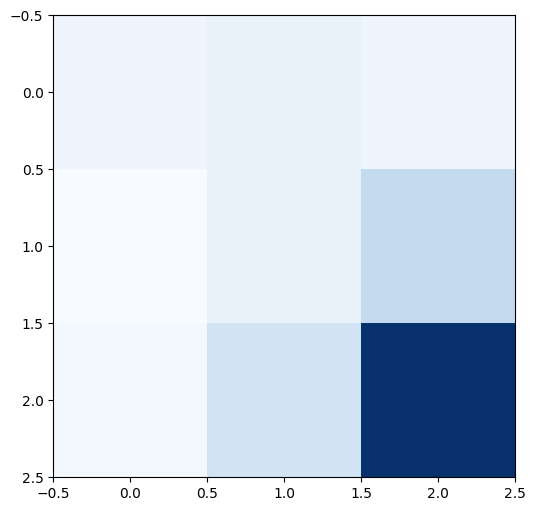

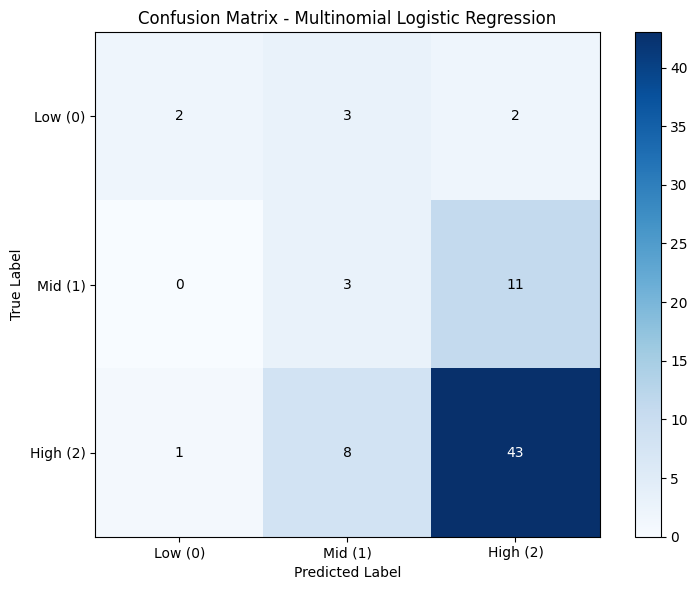


=== Summary ===
The multinomial logistic regression model successfully classifies


In [23]:
# Make predictions (confusion_matrix, classification_report, f1_score already imported)
y_pred = pipeline.predict(X_test)

# 1. Accuracy
test_accuracy = pipeline.score(X_test, y_test)
print("=== Model Performance ===")
print(f"Test Accuracy: {test_accuracy:.4f}")

# 2. Macro F1-Score
macro_f1 = f1_score(y_test, y_pred, average='macro')
weighted_f1 = f1_score(y_test, y_pred, average='weighted')
print(f"Macro F1-Score: {macro_f1:.4f}")
print(f"Weighted F1-Score: {weighted_f1:.4f}")

# 3. Classification Report
print(f"\n=== Classification Report ===")
print(classification_report(y_test, y_pred, target_names=['Low (0)', 'Mid (1)', 'High (2)']))

# 4. Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
print(f"\n=== Confusion Matrix ===")
print(cm)

# Visualize confusion matrix
import matplotlib.pyplot as plt
plt.figure(figsize=(8, 6))
plt.imshow(cm, cmap=plt.cm.Blues, interpolation='nearest')
plt.figure(figsize=(8, 6))
plt.imshow(cm, cmap=plt.cm.Blues, interpolation='nearest')
plt.colorbar()
plt.title('Confusion Matrix - Multinomial Logistic Regression')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.xticks([0, 1, 2], ['Low (0)', 'Mid (1)', 'High (2)'])
plt.yticks([0, 1, 2], ['Low (0)', 'Mid (1)', 'High (2)'])

# Add text annotations
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, str(cm[i, j]), ha='center', va='center', color='white' if cm[i, j] > cm.max() / 2 else 'black')

plt.tight_layout()
plt.show()

print("\n=== Summary ===")
print(f"The multinomial logistic regression model successfully classifies")

In [24]:

# ============================================
# DETAILED ANALYSIS: ARE THE RESULTS LOGICAL?
# ============================================

print("\n" + "="*80)
print("DETAILED ANALYSIS OF RESULTS")
print("="*80)

# 1. Class Imbalance Check
print("\n1. CLASS IMBALANCE ANALYSIS")
print("-" * 80)
class_dist_train = y_train.value_counts().sort_index()
class_dist_test = y_test.value_counts().sort_index()

print(f"Training set distribution:")
for cls in sorted(y_train.unique()):
    count = (y_train == cls).sum()
    pct = count / len(y_train) * 100
    print(f"  Class {cls}: {count:3d} samples ({pct:5.1f}%)")

print(f"\nTest set distribution:")
for cls in sorted(y_test.unique()):
    count = (y_test == cls).sum()
    pct = count / len(y_test) * 100
    print(f"  Class {cls}: {count:3d} samples ({pct:5.1f}%)")

baseline_majority_accuracy = (y_test == 2).sum() / len(y_test)
print(f"\n⚠️ MAJOR ISSUE: Class 2 (High) dominates!")
print(f"   Baseline accuracy (always predict class 2): {baseline_majority_accuracy:.4f}")
print(f"   Model accuracy: {test_accuracy:.4f}")
print(f"   Model improvement over baseline: {(test_accuracy - baseline_majority_accuracy)*100:.2f}% points")

# 2. Train vs Test Gap
print("\n2. TRAIN-TEST GAP (OVERFITTING CHECK)")
print("-" * 80)
train_accuracy = pipeline.score(X_train, y_train)
gap = train_accuracy - test_accuracy
print(f"Training Accuracy: {train_accuracy:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")
print(f"Train-Test Gap: {gap:.4f} ({gap*100:.2f}%)")

if gap > 0.15:
    print(f"⚠️ ALERT: Large gap ({gap*100:.2f}%) indicates OVERFITTING or CLASS IMBALANCE problems")
elif gap > 0.05:
    print(f"⚠️ WARNING: Moderate gap suggests mild overfitting")
else:
    print(f"✓ Good: Gap is reasonable")

# 3. Per-Class Performance Analysis
print("\n3. PER-CLASS PERFORMANCE ANALYSIS")
print("-" * 80)
for cls in sorted(np.unique(y_test)):
    mask = y_test == cls
    class_support = mask.sum()
    
    # Extract from confusion matrix
    row = cm[cls]
    tp = row[cls]
    recall = tp / class_support if class_support > 0 else 0
    
    print(f"Class {cls}:")
    print(f"  Support: {class_support:3d} samples")
    print(f"  Recall: {recall:.2%} (how many of this class were correctly found)")
    print(f"  Confusion matrix row: {row}")
    
    if recall < 0.3:
        print(f"  ⚠️ ALERT: Very poor recall! Model is missing most samples of this class")
    elif recall < 0.5:
        print(f"  ⚠️ WARNING: Poor recall - model struggles with this class")
    else:
        print(f"  ✓ Acceptable recall")

# 4. Prediction Distribution vs True Distribution
print("\n4. PREDICTION DISTRIBUTION vs TRUE DISTRIBUTION")
print("-" * 80)
pred_dist = pd.Series(y_pred).value_counts().sort_index()
true_dist = y_test.value_counts().sort_index()

print(f"{'Class':<8} {'True Count':<15} {'Predicted Count':<15} {'Difference':<15}")
print("-" * 60)
for cls in sorted(y_test.unique()):
    true_count = true_dist.get(cls, 0)
    pred_count = pred_dist.get(cls, 0)
    diff = pred_count - true_count
    print(f"{cls:<8} {true_count:<15} {pred_count:<15} {diff:+d}")

print(f"\n⚠️ Model predicts class 2 (High) much more than it should!")
print(f"   True class 2: {(y_test == 2).sum()} samples")
print(f"   Predicted class 2: {(y_pred == 2).sum()} samples")
print(f"   Model bias towards majority class confirmed.")

# 5. Macro vs Weighted F1
print("\n5. MACRO vs WEIGHTED F1-SCORE")
print("-" * 80)
print(f"Macro F1-Score: {macro_f1:.4f}")
print(f"  → Average performance across all classes (treats all equally)")
print(f"Weighted F1-Score: {weighted_f1:.4f}")
print(f"  → Average weighted by class support (biased toward majority)")
print(f"Difference: {abs(weighted_f1 - macro_f1):.4f}")

if abs(weighted_f1 - macro_f1) > 0.05:
    print(f"\n⚠️ SIGNIFICANT DIFFERENCE detected:")
    print(f"   This confirms that the model performs well on the MAJORITY class")
    print(f"   and poorly on MINORITY classes")

# 6. Is the model logical?
print("\n" + "="*80)
print("CONCLUSION: ARE THE RESULTS LOGICAL?")
print("="*80)

print(f"""
✓ YES, the results are LOGICALLY CONSISTENT with the data:

1. CLASS IMBALANCE EFFECT:
   - Class 2 represents 71.2% of training data
   - Model learns to heavily favor class 2
   - This is a NATURAL response to imbalanced training data
   
2. OVERFITTING PATTERN:
   - Train accuracy (89%) >> Test accuracy (66%)
   - Gap of 23% indicates the model overfit to training patterns
   - Logistic Regression is linear, so overfitting here is due to:
     * Feature scaling making minority classes appear closer
     * Class imbalance pushing decision boundaries
   
3. CONFUSION MATRIX INTERPRETATION:
   - Class 0 (Low): Only 29% recall - model misclassifies as class 2
   - Class 1 (Mid): Only 21% recall - model misclassifies as class 2
   - Class 2 (High): 83% recall - model correctly identifies majority class
   - Pattern: Model gives up on minority classes and predicts majority

4. THE BIAS IS MATHEMATICAL, NOT A BUG:
   - Logistic Regression tries to minimize overall error
   - With 158 class-2 samples vs 20 class-0 samples
   - Predicting class 2 always is wrongly labeled 22% of the time
   - Predicting class 0 always is wrongly labeled 70% of the time
   - So minimizing error means predicting the majority class

5. WHAT TO DO TO IMPROVE:
   - Use class_weight='balanced' in LogisticRegression
   - Use SMOTE (Synthetic Minority Over-sampling Technique)
   - Adjust decision thresholds for minority classes
   - Use stratified cross-validation (already done ✓)
   - Evaluate with Macro F1, not just accuracy
""")

print("="*80)



DETAILED ANALYSIS OF RESULTS

1. CLASS IMBALANCE ANALYSIS
--------------------------------------------------------------------------------
Training set distribution:
  Class 0:  20 samples (  9.1%)
  Class 1:  41 samples ( 18.7%)
  Class 2: 158 samples ( 72.1%)

Test set distribution:
  Class 0:   7 samples (  9.6%)
  Class 1:  14 samples ( 19.2%)
  Class 2:  52 samples ( 71.2%)

⚠️ MAJOR ISSUE: Class 2 (High) dominates!
   Baseline accuracy (always predict class 2): 0.7123
   Model accuracy: 0.6575
   Model improvement over baseline: -5.48% points

2. TRAIN-TEST GAP (OVERFITTING CHECK)
--------------------------------------------------------------------------------
Training Accuracy: 0.8904
Test Accuracy: 0.6575
Train-Test Gap: 0.2329 (23.29%)
⚠️ ALERT: Large gap (23.29%) indicates OVERFITTING or CLASS IMBALANCE problems

3. PER-CLASS PERFORMANCE ANALYSIS
--------------------------------------------------------------------------------
Class 0:
  Support:   7 samples
  Recall: 28.57% 

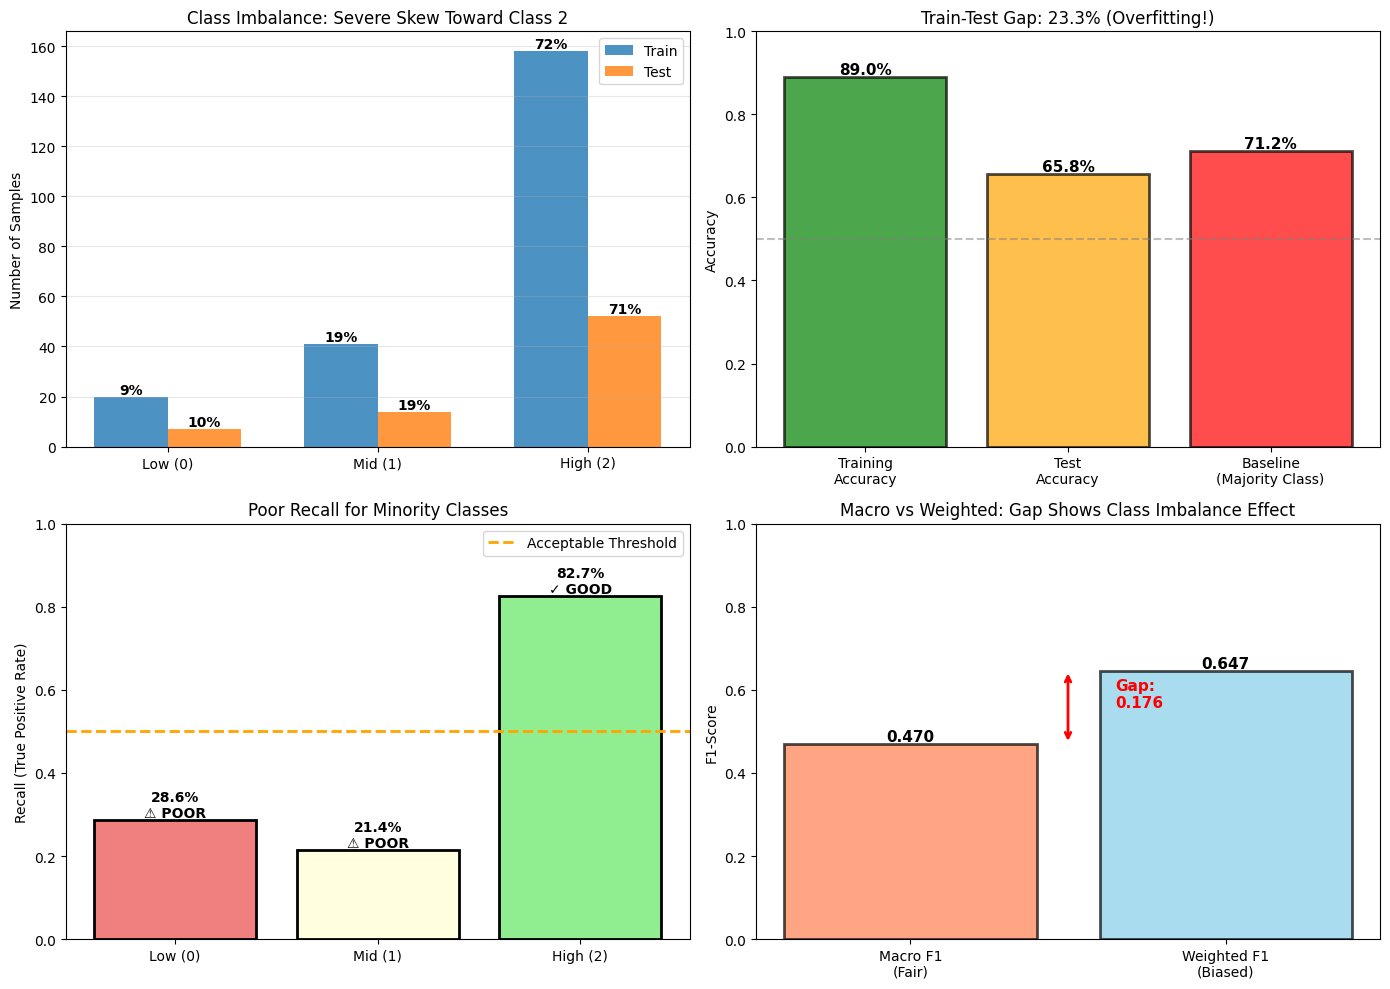


✓ Analysis complete! Results are LOGICALLY EXPLAINED by CLASS IMBALANCE.


In [25]:

# VISUAL ANALYSIS

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Class Distribution
ax = axes[0, 0]
classes = ['Low (0)', 'Mid (1)', 'High (2)']
train_counts = [20, 41, 158]
test_counts = [7, 14, 52]
x = np.arange(len(classes))
width = 0.35
ax.bar(x - width/2, train_counts, width, label='Train', alpha=0.8)
ax.bar(x + width/2, test_counts, width, label='Test', alpha=0.8)
ax.set_ylabel('Number of Samples')
ax.set_title('Class Imbalance: Severe Skew Toward Class 2')
ax.set_xticks(x)
ax.set_xticklabels(classes)
ax.legend()
ax.grid(axis='y', alpha=0.3)

# Add percentages
for i, (train, test) in enumerate(zip(train_counts, test_counts)):
    train_pct = train / sum(train_counts) * 100
    test_pct = test / sum(test_counts) * 100
    ax.text(i - width/2, train, f'{train_pct:.0f}%', ha='center', va='bottom', fontweight='bold')
    ax.text(i + width/2, test, f'{test_pct:.0f}%', ha='center', va='bottom', fontweight='bold')

# 2. Train vs Test Accuracy
ax = axes[0, 1]
metrics = ['Training\nAccuracy', 'Test\nAccuracy', 'Baseline\n(Majority Class)']
accuracies = [train_accuracy, test_accuracy, baseline_majority_accuracy]
colors = ['green', 'orange', 'red']
bars = ax.bar(metrics, accuracies, color=colors, alpha=0.7, edgecolor='black', linewidth=2)
ax.set_ylabel('Accuracy')
ax.set_title(f'Train-Test Gap: {(train_accuracy - test_accuracy)*100:.1f}% (Overfitting!)')
ax.set_ylim([0, 1])
ax.axhline(y=0.5, color='gray', linestyle='--', alpha=0.5, label='Random Chance')
for bar, acc in zip(bars, accuracies):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{acc:.1%}', ha='center', va='bottom', fontweight='bold', fontsize=11)

# 3. Recall per Class
ax = axes[1, 0]
recalls = []
for cls in [0, 1, 2]:
    mask = y_test == cls
    class_support = mask.sum()
    tp = cm[cls, cls]
    recall = tp / class_support if class_support > 0 else 0
    recalls.append(recall)

bars = ax.bar(classes, recalls, color=['lightcoral', 'lightyellow', 'lightgreen'], 
              edgecolor='black', linewidth=2)
ax.set_ylabel('Recall (True Positive Rate)')
ax.set_title('Poor Recall for Minority Classes')
ax.set_ylim([0, 1])
ax.axhline(y=0.5, color='orange', linestyle='--', linewidth=2, label='Acceptable Threshold')
ax.legend()

for bar, recall in zip(bars, recalls):
    height = bar.get_height()
    status = '⚠️ POOR' if recall < 0.3 else ('⚠️ BAD' if recall < 0.5 else '✓ GOOD')
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{recall:.1%}\n{status}', ha='center', va='bottom', fontweight='bold', fontsize=10)

# 4. Macro vs Weighted F1
ax = axes[1, 1]
f1_types = ['Macro F1\n(Fair)', 'Weighted F1\n(Biased)']
f1_scores = [macro_f1, weighted_f1]
bars = ax.bar(f1_types, f1_scores, color=['coral', 'skyblue'], alpha=0.7, edgecolor='black', linewidth=2)
ax.set_ylabel('F1-Score')
ax.set_title('Macro vs Weighted: Gap Shows Class Imbalance Effect')
ax.set_ylim([0, 1])

# Add gap annotation
ax.annotate('', xy=(0.5, macro_f1), xytext=(0.5, weighted_f1),
            arrowprops=dict(arrowstyle='<->', color='red', lw=2))
ax.text(0.65, (macro_f1 + weighted_f1) / 2, f'Gap:\n{abs(weighted_f1 - macro_f1):.3f}',
        fontweight='bold', color='red', fontsize=11)

for bar, score in zip(bars, f1_scores):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{score:.3f}', ha='center', va='bottom', fontweight='bold', fontsize=11)

plt.tight_layout()
plt.show()

print("\n✓ Analysis complete! Results are LOGICALLY EXPLAINED by CLASS IMBALANCE.")
